In [1]:
import pandas as pd
import matplotlib . pyplot as plt
import pylab


In [2]:
data = r"C:\Users\Baptiste\Downloads\data.csv"
df = pd.read_csv ( data , sep =",", decimal =".", engine ='python' )
df.head()
df.shape

(234, 28)

Exercice 1

In [3]:
df.dtypes

STATION               int64
DATE                    str
LATITUDE            float64
LONGITUDE           float64
ELEVATION           float64
NAME                    str
TEMP                float64
TEMP_ATTRIBUTES       int64
DEWP                float64
DEWP_ATTRIBUTES       int64
SLP                 float64
SLP_ATTRIBUTES        int64
STP                 float64
STP_ATTRIBUTES        int64
VISIB               float64
VISIB_ATTRIBUTES      int64
WDSP                float64
WDSP_ATTRIBUTES       int64
MXSPD               float64
GUST                float64
MAX                 float64
MAX_ATTRIBUTES          str
MIN                 float64
MIN_ATTRIBUTES          str
PRCP                float64
PRCP_ATTRIBUTES         str
SNDP                float64
FRSHTT                int64
dtype: object

In [4]:
# Name of columns without spaces and in lower case
df.columns = map( str. strip , df . columns )
df.columns = map( str. lower , df . columns )

In [5]:
df.columns

Index(['station', 'date', 'latitude', 'longitude', 'elevation', 'name', 'temp',
       'temp_attributes', 'dewp', 'dewp_attributes', 'slp', 'slp_attributes',
       'stp', 'stp_attributes', 'visib', 'visib_attributes', 'wdsp',
       'wdsp_attributes', 'mxspd', 'gust', 'max', 'max_attributes', 'min',
       'min_attributes', 'prcp', 'prcp_attributes', 'sndp', 'frshtt'],
      dtype='str')

In [6]:
df.drop ( df . columns [[27]] , axis =1 , inplace = True )
#Here inplace means we want to modify the base df and not create a copy. The axis=1 means we are talking about a column and not a line

Exercice 2

In [7]:

#Here we take the name of columns we want to take and we put them in an array
keep_cols = [
    "station", "date", "latitude", "longitude", "elevation",
    "name", "temp", "dewp", "slp", "stp", "visib", "wdsp",
    "mxspd", "gust", "max", "min", "prcp"
]

#Based on the columns we want to keep, we determine the ones to drop with a boucle.
cols_to_drop = [col for col in df.columns if col not in keep_cols]

#We drop the columns we don't want
df.drop(columns=cols_to_drop, inplace=True)

#Here inplace means we want to modify the base df and not create a copy

#HERE DEPWS IN THE PDF DOCS ISN'T PRESENT IN OUR DATAFRAME, I ASSUMED THE ERROR AND MODIFIED THE KEEP COLS NAMES

In [8]:
print(df["temp"].mean())

68.84700854700854


Exercice 3

In [9]:
def info_att(feature):
    print("Mean: ", feature.mean())
    print("Minimum: ", feature.min())
    print("Maximum: ",feature.max())

info_att(df['temp'])

#OR WE CAN DO:

def info_att2(feature):
    return feature.mean(), feature.min(), feature.max()

print(info_att2(df['temp']))

Mean:  68.84700854700854
Minimum:  59.1
Maximum:  78.2
(np.float64(68.84700854700854), np.float64(59.1), np.float64(78.2))


Exercice 4

In [10]:
import pandas as pd

import numpy as np

def info_att(feature):
    
    if feature.dtype in [int, float, 'int64', 'float64', 'int32', 'float32']:
        print("Mean: ", feature.mean())
        print("Minimum: ", feature.min())
        print("Maximum: ", feature.max())
    else:
        print("Erreur : la colonne n'est pas numérique.")


info_att(df['temp'])
'''
def info_att(feature):
    # Vérifie si le type de données est numérique (int ou float)
    if pd.api.types.is_numeric_dtype(feature):
        print("Mean: ", feature.mean())
        print("Minimum: ", feature.min())
        print("Maximum: ", feature.max())
    else:
        print("Erreur : la colonne n'est pas numérique.")

#OR WE CAN DO

def info_att2(feature):
    if feature.dtype.kind in 'iifu':  # 'i' = int, 'f' = float, 'u' = unsigned int
        print("Mean: ", feature.mean())
        print("Minimum: ", feature.min())
        print("Maximum: ", feature.max())
    else:
        print("Erreur : la colonne n'est pas numérique.")
'''
#info_att(df['temp'])
#info_att2(df['temp'])

Mean:  68.84700854700854
Minimum:  59.1
Maximum:  78.2


'\ndef info_att(feature):\n    # Vérifie si le type de données est numérique (int ou float)\n    if pd.api.types.is_numeric_dtype(feature):\n        print("Mean: ", feature.mean())\n        print("Minimum: ", feature.min())\n        print("Maximum: ", feature.max())\n    else:\n        print("Erreur : la colonne n\'est pas numérique.")\n\n#OR WE CAN DO\n\ndef info_att2(feature):\n    if feature.dtype.kind in \'iifu\':  # \'i\' = int, \'f\' = float, \'u\' = unsigned int\n        print("Mean: ", feature.mean())\n        print("Minimum: ", feature.min())\n        print("Maximum: ", feature.max())\n    else:\n        print("Erreur : la colonne n\'est pas numérique.")\n'

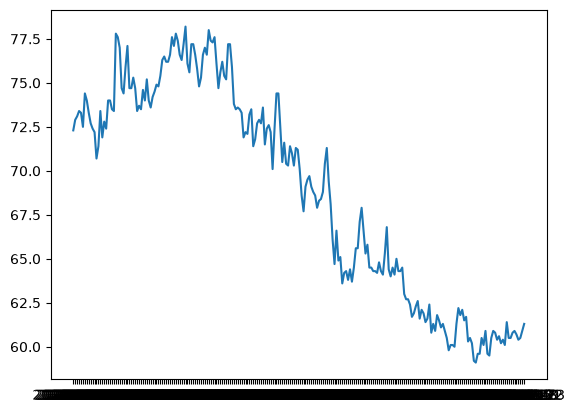

In [11]:
x = df["date"]
y = df ["temp"]
plt.plot (x , y )
pylab.show()

Exercice 5

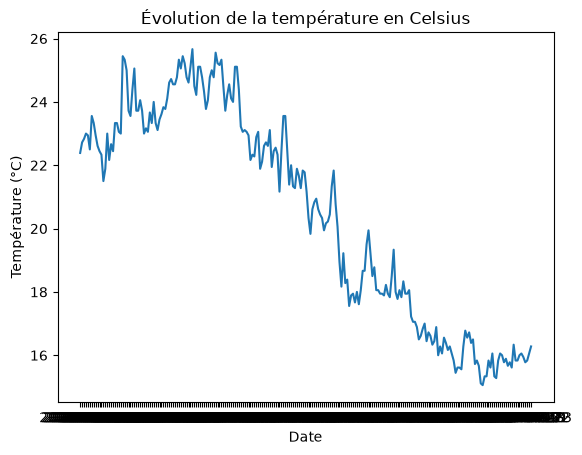

In [12]:
df["temp_celsius"] = (df["temp"] - 32) * (5 / 9)


x = df["date"]
y = df["temp_celsius"]

plt.plot(x, y)
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Évolution de la température en Celsius")

pylab.show()

PART 3

In [13]:
def dataframe_arff(dataframe, filename="output.arff", relation_name="weather_data"):
    
    with open(filename, "w", encoding="utf-8") as f:
        
        f.write(f"@relation {relation_name}\n\n")
        
        
        for col in dataframe.columns:
            
            if pd.api.types.is_numeric_dtype(dataframe[col]):
                f.write(f"@attribute {col} numeric\n")
            else:
                f.write(f"@attribute {col} string\n")
        
        f.write("\n@data\n")
        
        
        for row in dataframe.itertuples(index=False):
           
            formatted_values = []
            for val in row:
                if pd.isna(val):
                    formatted_values.append("?")  
                elif isinstance(val, str):
                    clean_val = val.replace('"', '\\"')  
                    formatted_values.append(f'"{clean_val}"')
                else:
                    formatted_values.append(str(val))
            
            f.write(",".join(formatted_values) + "\n")

    print(f"Fichier sauvegardé avec succès : {filename}")

dataframe_arff(df, "data_meteo.arff")


Fichier sauvegardé avec succès : data_meteo.arff
